### 14_EDA_Mini_Challenge

In [24]:
### Load the dataset.

import pandas as pd
import numpy as np

df = pd.read_csv("cancer_prediction_uncleaned.csv")
df

,Patient_ID,Age,Gender,Tumor_Size_cm,Cell_Count,Weight_kg,Smoking,Family_History,Pain,Cancer
0,P1001,63.0,Female,0.6,53,105.9,Yes,No,Yes,No
1,P1002,53.0,Male,2.0,33,53.9,No,Yes,Yes,No
2,P1003,39.0,Female,5.8,88,67.2,Yes,Yes,No,Yes
3,P1004,67.0,female,6.4,68,52.4,No,No,No,Yes
4,P1005,32.0,Male,5.0,41,105.1,No,Yes,Yes,No
5,P1006,NaN,Male,7.4,97,102.0,No,No,No,Yes
6,P1007,63.0,Male,5.4,61,61.8,Yes,Yes,No,Yes
7,P1008,43.0,Male,7.4,71,87.9,No,No,No,Yes
8,P1009,47.0,Male,6.9,67,98.1,NaN,Yes,Yes,Yes
9,P1010,35.0,Male,3.9,61,81.1,No,No,Yes,No


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient_ID      39 non-null     object 
 1   Age             37 non-null     float64
 2   Gender          39 non-null     object 
 3   Tumor_Size_cm   38 non-null     float64
 4   Cell_Count      39 non-null     int64  
 5   Weight_kg       37 non-null     float64
 6   Smoking         38 non-null     object 
 7   Family_History  38 non-null     object 
 8   Pain            39 non-null     object 
 9   Cancer          39 non-null     object 
dtypes: float64(3), int64(1), object(6)
memory usage: 3.2+ KB


In [26]:
df.describe()

,Age,Tumor_Size_cm,Cell_Count,Weight_kg
count,37.000000,38.000000,39.000000,37.000000
mean,52.729730,5.113158,54.179487,82.462162
std,17.925228,3.891583,27.096195,34.545569
min,26.000000,0.600000,10.000000,45.300000
25%,40.000000,2.800000,33.000000,60.400000
50%,49.000000,5.000000,61.000000,84.400000
75%,64.000000,5.875000,74.000000,95.700000
max,120.000000,25.000000,99.000000,250.000000


In [27]:
df.size

390

In [28]:
df.dtypes

Patient_ID         object
Age               float64
Gender             object
Tumor_Size_cm     float64
Cell_Count          int64
Weight_kg         float64
Smoking            object
Family_History     object
Pain               object
Cancer             object
dtype: object

In [37]:
# Identify missing values.

missing_count_df = df.isnull().sum().sum()

display(df.isnull().sum())

print("missing count:", missing_count)



Patient_ID        0
Age               2
Gender            0
Tumor_Size_cm     1
Cell_Count        0
Weight_kg         2
Smoking           1
Family_History    1
Pain              0
Cancer            0
dtype: int64

missing count: 7


In [40]:
missing_categorical = df.select_dtypes(include = "object").columns

print(missing_categorical)

missing_numerical = df.select_dtypes(include = "number").columns

print("missing_numerical:", missing_numerical)


Index(['Patient_ID', 'Gender', 'Smoking', 'Family_History', 'Pain', 'Cancer'], dtype='object')


np.int64(0)

missing_numerical: Index(['Age', 'Tumor_Size_cm', 'Cell_Count', 'Weight_kg'], dtype='object')


In [41]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [68]:
print("\n7. Analyze numerical features")
numerical_cols = df.select_dtypes(include=np.number).columns
display(df[numerical_cols].describe())



7. Analyze numerical features


,Age,Tumor_Size_cm,Cell_Count,Weight_kg
count,39.000000,39.000000,39.000000,39.000000
mean,52.729730,5.113158,54.179487,82.462162
std,17.447136,3.840036,27.096195,33.624187
min,26.000000,0.600000,10.000000,45.300000
25%,41.500000,3.000000,33.000000,60.550000
50%,51.000000,5.000000,61.000000,82.462162
75%,63.500000,5.850000,74.000000,93.950000
max,120.000000,25.000000,99.000000,250.000000


In [53]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

In [54]:
display(df[numerical_cols])


,Age,Tumor_Size_cm,Cell_Count,Weight_kg
0,63.00000,0.600000,53,105.900000
1,53.00000,2.000000,33,53.900000
2,39.00000,5.800000,88,67.200000
3,67.00000,6.400000,68,52.400000
4,32.00000,5.000000,41,105.100000
5,52.72973,7.400000,97,102.000000
6,63.00000,5.400000,61,61.800000
7,43.00000,7.400000,71,87.900000
8,47.00000,6.900000,67,98.100000
9,35.00000,3.900000,61,81.100000


In [57]:
df[numerical_cols].isnull().sum().sum()

np.int64(0)

In [58]:
print("\n8. Analyze categorical features")
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


8. Analyze categorical features

Patient_ID
Patient_ID
P1001    1
P1030    1
P1023    1
P1024    1
P1025    1
P1026    1
P1027    1
P1028    1
P1029    1
P1031    1
P1021    1
P1032    1
P1033    1
P1034    1
P1035    1
P1036    1
P1037    1
P1038    1
P1022    1
P1020    1
P1002    1
P1010    1
P1003    1
P1004    1
P1005    1
P1006    1
P1007    1
P1008    1
P1009    1
P1011    1
P1019    1
P1012    1
P1013    1
P1014    1
P1015    1
P1016    1
P1017    1
P1018    1
P1039    1
Name: count, dtype: int64

Gender
Gender
Male      26
Female    11
female     1
MALE       1
Name: count, dtype: int64

Smoking
Smoking
Yes    19
No     18
NaN     1
yes     1
Name: count, dtype: int64

Family_History
Family_History
No     20
Yes    18
NaN     1
Name: count, dtype: int64

Pain
Pain
No     20
Yes    19
Name: count, dtype: int64

Cancer
Cancer
Yes    22
No     17
Name: count, dtype: int64


In [61]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mean)

In [65]:
df[categorical_cols].isnull().sum().sum()

np.int64(0)

In [64]:
display(df[categorical_cols])

,Patient_ID,Gender,Smoking,Family_History,Pain,Cancer
0,P1001,Female,Yes,No,Yes,No
1,P1002,Male,No,Yes,Yes,No
2,P1003,Female,Yes,Yes,No,Yes
3,P1004,female,No,No,No,Yes
4,P1005,Male,No,Yes,Yes,No
5,P1006,Male,No,No,No,Yes
6,P1007,Male,Yes,Yes,No,Yes
7,P1008,Male,No,No,No,Yes
8,P1009,Male,<bound method Series.mean of 0 Yes\n1 ...,Yes,Yes,Yes
9,P1010,Male,No,No,Yes,No


In [69]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, ":", len(outliers), "outliers")

Age : 1 outliers
Tumor_Size_cm : 1 outliers
Cell_Count : 0 outliers
Weight_kg : 1 outliers


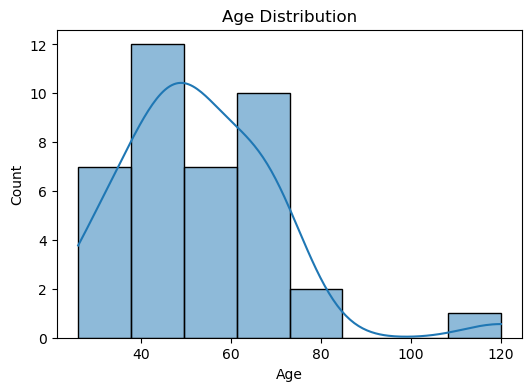

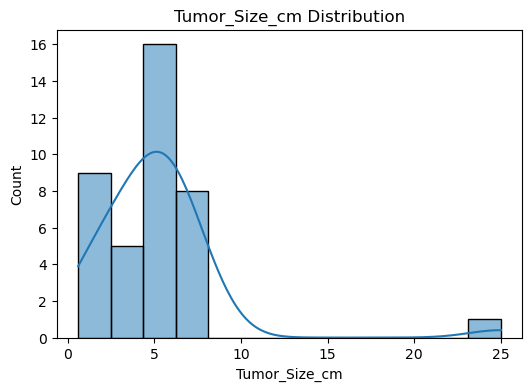

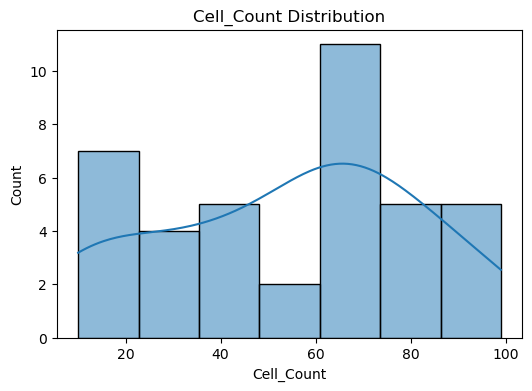

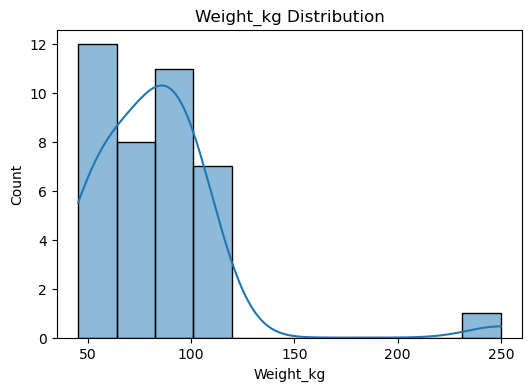

In [75]:
# Analyze Distributions
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:

    plt.figure(figsize=(6, 4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col + " Distribution")
    plt.show()

In [84]:
# Analyze Correlations
correlation = df[numerical_cols].corr()
print(correlation)

                    Age  Tumor_Size_cm  Cell_Count  Weight_kg
Age            1.000000      -0.079036   -0.224147  -0.320852
Tumor_Size_cm -0.079036       1.000000    0.143941   0.158078
Cell_Count    -0.224147       0.143941    1.000000   0.133100
Weight_kg     -0.320852       0.158078    0.133100   1.000000


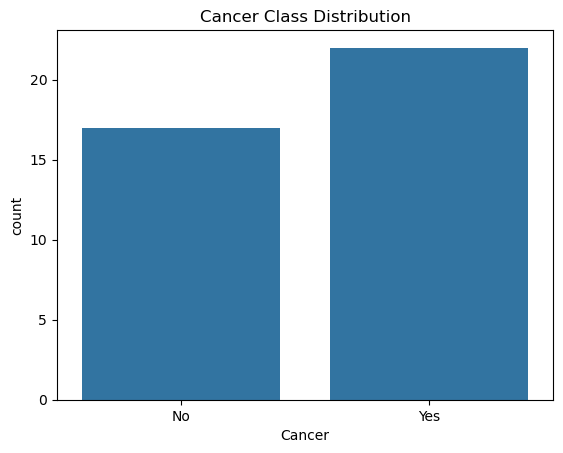

In [88]:
#Cancer Class Distribution

sns.countplot(data=df,
              x="Cancer")

plt.title("Cancer Class Distribution")
plt.show()

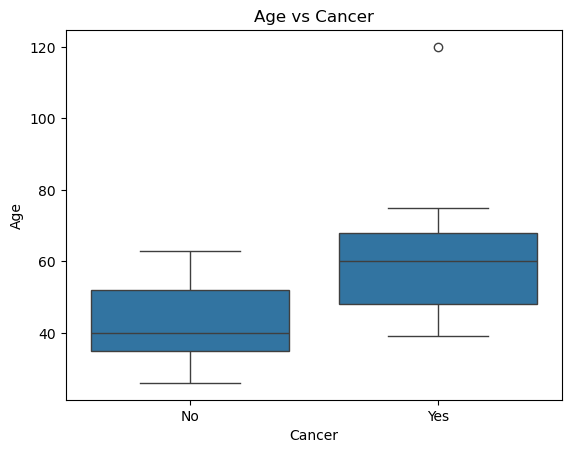

In [89]:
#age vs cancer

sns.boxplot(
    data=df,
    x="Cancer",
    y="Age"
)

plt.title("Age vs Cancer")
plt.show()

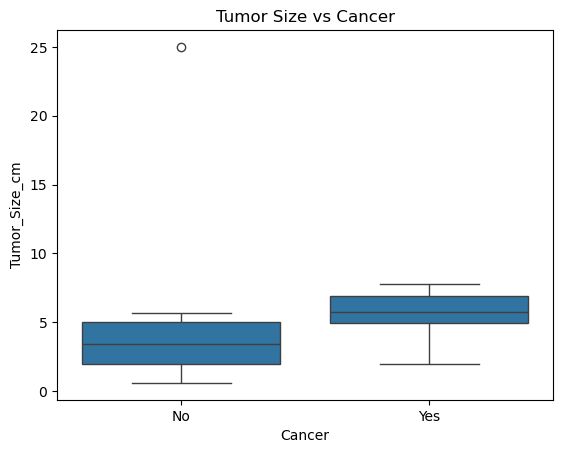

In [90]:
#cancer vs tumpor
sns.boxplot(
    data=df,
    x="Cancer",
    y="Tumor_Size_cm"
)

plt.title("Tumor Size vs Cancer")
plt.show()

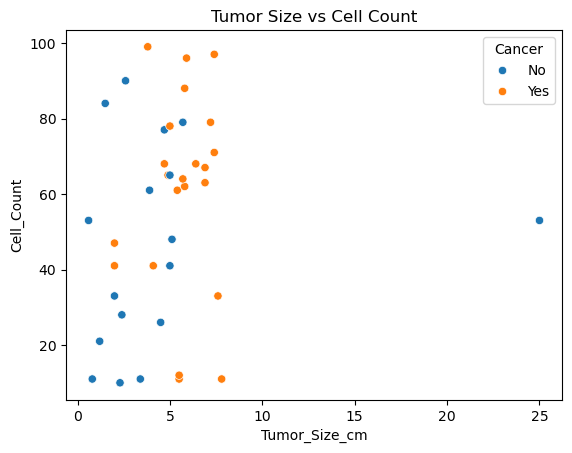

In [91]:
# Tumor Size vs Cell Count
sns.scatterplot(
    data=df,
    x="Tumor_Size_cm",
    y="Cell_Count",
    hue="Cancer"
)


plt.title("Tumor Size vs Cell Count")
plt.show()

In [95]:
#important pattern

df.groupby("Cancer")[["Age", "Tumor_Size_cm", "Cell_Count", "Weight_kg"]].mean()

,Age,Tumor_Size_cm,Cell_Count,Weight_kg
Cancer,,,,
No,42.572337,4.453715,46.529412,89.982353
Yes,60.578624,5.622727,60.090909,76.651106


In [96]:
#Write Business Insights
print("Business Insights")


print("1. The dataset contains patient-level information for cancer prediction.")


print("2. Tumor size and cell count should be investigated as potentially important features.")


print("3. Age, smoking status, and family history can be compared between cancer classes.")


print("4. Missing values, duplicate records, inconsistent categories, and outliers are present and should be reviewed.")


print("5. The Cancer target should be checked for class imbalance before model training.")

Business Insights
1. The dataset contains patient-level information for cancer prediction.
2. Tumor size and cell count should be investigated as potentially important features.
3. Age, smoking status, and family history can be compared between cancer classes.
4. Missing values, duplicate records, inconsistent categories, and outliers are present and should be reviewed.
5. The Cancer target should be checked for class imbalance before model training.
